# Casting Defect Inspection — Clean Rebuild (v2)

Trains and **fairly compares three models** on the casting dataset (`def_front` = defective = positive class,
`ok_front` = good):

| key | model | strategy |
|---|---|---|
| `custom_cnn` | small CNN | trained from scratch |
| `effnet_b0_finetune` | EfficientNet-B0 | ImageNet weights, **all** layers trained |
| `effnet_b1_frozen` | EfficientNet-B1 | ImageNet weights, backbone **frozen** (transfer learning), only the head trained |

Note: `effnet_b0_finetune` vs `effnet_b1_frozen` differs in **both** architecture (B0 vs B1) and strategy (full fine-tune vs
frozen), so any gap between them cannot be attributed to the strategy alone. Say so in the write-up.

## What changed compared with the previous run
1. **Near-duplicates are handled in a calibrated, non-destructive way.** The old filter (pHash ≤ 6) flagged 87% of the test set
   because every casting looks alike. Now we compare against a train→train baseline, use a strict threshold, also check
   flipped/rotated copies, and report on the **full test set *and* a strict "no near-duplicate" subset**.
2. **Grouped validation split** — near-copies can no longer sit on both sides of train/val.
3. **Brightness-only baseline** — tells us how much of the task lighting alone can solve.
4. **"Frozen" backbones are really frozen** (kept in `eval()` mode so BatchNorm stats and stochastic depth don't drift).
5. **Stabler training**: AdamW, weight decay, gradient clipping, seeded loaders. Same policy for every model.
6. **Loss weights no longer make defects cheaper than false alarms**, and the **decision threshold is tuned on validation**
   with an explicit cost for a missed defect.
7. **Honest reporting**: confusion matrices, specificity, Wilson confidence intervals, train accuracy measured in eval mode.
8. **Robustness tests, error analysis and Grad-CAM** to check the models look at defects, not lighting.
9. **Everything is saved to Google Drive** (weights, histories, results, inference config). Re-running loads saved models
   instead of retraining.

## How to run
1. Runtime ▸ Change runtime type ▸ **GPU**.
2. Check the paths in the CONFIG cell (`ZIP_PATH`, `CKPT_DIR`).
3. Runtime ▸ **Run all**. A full run on a T4 takes roughly 20–40 minutes.
4. If section 10 reports a brightness shortcut, set `NORMALIZE_BRIGHTNESS = True` and `RUN_TAG = "brightness_norm"`, then run again.

## 1. Setup

In [1]:
%pip install -q imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 12.3 MB/s eta 0:00:00


In [2]:
import os, sys, json, copy, time, random, hashlib, zipfile, warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.transforms.functional as TF
from torchvision.models import EfficientNet_B0_Weights, EfficientNet_B1_Weights

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, f1_score, roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)
import imagehash

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
# ============================== CONFIG ==============================
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

# Training policy (identical for every model)
MAX_EPOCHS = 20
EARLY_STOP_PATIENCE = 5
LR_PATIENCE = 2
LR_FACTOR = 0.5
GRAD_CLIP = 1.0

# Data hygiene
NEAR_DUP_THRESHOLD = 2     # pHash Hamming distance (0-64). <=2 means "visually the same image". Calibrated in section 4.
VAL_FOLDS = 5              # one fold (20%) becomes the validation set

# Loss / decision policy
DEFECT_WEIGHT_BOOST = 1.3  # multiplies the "balanced" loss weight of the defect class (see section 7)
COST_FN = 5.0              # cost of MISSING a defective part ...
COST_FP = 1.0              # ... versus the cost of a false alarm. Used to tune the threshold on VALIDATION.

# Augmentation
AUG_ROTATION = 15
AUG_BRIGHTNESS = 0.25
AUG_CONTRAST = 0.20
USE_VFLIP = True
NORMALIZE_BRIGHTNESS = False   # set True (and change RUN_TAG) if section 10 shows a brightness shortcut

# Models
PRETRAINED = True
FORCE_RETRAIN = False
MODELS_TO_RUN = ["custom_cnn", "effnet_b0_finetune", "effnet_b1_frozen"]

# Paths
RUN_TAG = "baseline"
ZIP_PATH = "/content/drive/MyDrive/casting_data.zip"
EXTRACT_DIR = "/content/data"
CKPT_DIR = f"/content/drive/MyDrive/casting_v2/{RUN_TAG}"

In [4]:
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    s = torch.initial_seed() % 2**32
    np.random.seed(s); random.seed(s)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cpu":
    print("WARNING: no GPU found. In Colab use Runtime > Change runtime type > GPU, otherwise training will be very slow.")

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

os.makedirs(CKPT_DIR, exist_ok=True)
print("Weights, histories and results will be saved to:", CKPT_DIR)

Device: cuda
Mounted at /content/drive
Weights, histories and results will be saved to: /content/drive/MyDrive/casting_v2/baseline


In [5]:
# ---------- Metric helpers used everywhere below ----------
def wilson(k, n, z=1.96):
    # 95% Wilson confidence interval for a proportion k/n
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (centre - half, centre + half)

def metrics_at(y, p, thr=0.5):
    # y: true labels (1 = defect), p: predicted probability of defect
    y = np.asarray(y); p = np.asarray(p)
    pred = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    rec = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    prec = tp / (tp + fp) if (tp + fp) else np.nan
    lo, _ = wilson(tp, tp + fn)
    out = dict(n=len(y), thr=round(float(thr), 3), acc=(tp + tn) / len(y), recall=rec, recall_lo95=lo,
               specificity=spec, precision=prec, f1=f1_score(y, pred, zero_division=0), FN=int(fn), FP=int(fp))
    if len(np.unique(y)) == 2:
        out["auc"] = roc_auc_score(y, p)
        out["pr_auc"] = average_precision_score(y, p)
    return out

def pick_threshold(y, p, cost_fn=COST_FN, cost_fp=COST_FP):
    # Choose the probability threshold that minimises  cost_fn*FN + cost_fp*FP  (ties -> middle of the tied range).
    y = np.asarray(y); p = np.asarray(p)
    grid = np.linspace(0.02, 0.98, 97)
    costs = []
    for t in grid:
        pred = p >= t
        costs.append(cost_fn * np.sum((y == 1) & ~pred) + cost_fp * np.sum((y == 0) & pred))
    costs = np.array(costs)
    best = np.flatnonzero(costs == costs.min())
    return float(grid[best[len(best) // 2]])

## 2. Locate the data and build the manifest

The cell below finds the dataset folder automatically (the one containing `train/` and `test/`), and unzips
`ZIP_PATH` only if the data is not already extracted.

In [6]:
CLASSES = ["ok_front", "def_front"]
LABEL_MAP = {"ok_front": 0, "def_front": 1}     # def_front = positive class
IDX_TO_CLASS = {v: k for k, v in LABEL_MAP.items()}

def find_casting_root(base):
    for dirpath, dirnames, _ in os.walk(base):
        if {"train", "test"} <= set(dirnames) and os.path.isdir(os.path.join(dirpath, "train", "def_front")):
            return dirpath
    return None

CASTING_ROOT = find_casting_root(EXTRACT_DIR) if os.path.isdir(EXTRACT_DIR) else None
if CASTING_ROOT is None:
    assert os.path.exists(ZIP_PATH), f"Dataset not found. Set ZIP_PATH (now: {ZIP_PATH}) or put the extracted data in {EXTRACT_DIR}."
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(EXTRACT_DIR)
    CASTING_ROOT = find_casting_root(EXTRACT_DIR)
assert CASTING_ROOT is not None, "Could not find a folder containing train/ and test/ with def_front/ ok_front/ inside."
print("CASTING_ROOT =", CASTING_ROOT)

CASTING_ROOT = /content/data/casting_data/casting_data


In [7]:
def build_manifest(root):
    rows = []
    for split in ["train", "test"]:
        for cls in CLASSES:
            folder = os.path.join(root, split, cls)
            for fname in sorted(os.listdir(folder)):
                if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                    rows.append(dict(filepath=os.path.join(folder, fname), filename=fname, split=split,
                                     label_name=cls, label=LABEL_MAP[cls]))
    return pd.DataFrame(rows)

def is_readable(path):
    try:
        with Image.open(path) as im:
            im.convert("RGB").load()
        return True
    except Exception:
        return False

df = build_manifest(CASTING_ROOT)
df["readable"] = [is_readable(p) for p in tqdm(df["filepath"], desc="readability check")]
print("Unreadable images:", int((~df["readable"]).sum()))
df = df[df["readable"]].drop(columns="readable").reset_index(drop=True)
display(pd.crosstab(df["split"], df["label_name"], margins=True))

readability check:   0%|          | 0/7348 [00:00<?, ?it/s]

Unreadable images: 0


label_name,def_front,ok_front,All
split,,,
test,453,262,715
train,3758,2875,6633
All,4211,3137,7348


## 3. Exact duplicates (MD5)

Besides removing exact copies we also check that copies **agree on the label** — if the same image is labelled both
`ok` and `def`, it is label noise and is dropped everywhere.

In [8]:
def md5_of(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

df["md5"] = [md5_of(p) for p in tqdm(df["filepath"], desc="md5")]

g = df.groupby("md5").agg(n=("label", "size"), n_labels=("label", "nunique"), n_splits=("split", "nunique"))
dup_groups = g[g["n"] > 1]
print(f"Exact-duplicate groups: {len(dup_groups)}  "
      f"(spanning train AND test: {int((dup_groups['n_splits'] > 1).sum())}, "
      f"with CONFLICTING labels: {int((dup_groups['n_labels'] > 1).sum())})")

conflict_md5 = set(g[g["n_labels"] > 1].index)
if conflict_md5:
    print(f"Dropping {len(conflict_md5)} duplicate groups whose copies carry conflicting labels.")
    df = df[~df["md5"].isin(conflict_md5)]

train_df = df[df["split"] == "train"].drop_duplicates("md5").copy()
test_df = df[df["split"] == "test"].copy()
n_before = len(test_df)
test_df = test_df[~test_df["md5"].isin(set(train_df["md5"]))].drop_duplicates("md5").copy()
print(f"Test images removed because an identical file is in train: {n_before - len(test_df)}")

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print(f"\nClean train pool: {len(train_df)}   Clean test set: {len(test_df)}")
display(pd.concat({"train": train_df["label_name"].value_counts(),
                   "test": test_df["label_name"].value_counts()}, axis=1))

md5:   0%|          | 0/7348 [00:00<?, ?it/s]

Exact-duplicate groups: 64  (spanning train AND test: 64, with CONFLICTING labels: 0)
Test images removed because an identical file is in train: 64

Clean train pool: 6633   Clean test set: 651


,train,test
label_name,,
def_front,3758,453
ok_front,2875,198


## 4. Near-duplicates (perceptual hash) — calibrated

All castings are the same part, centred and similarly lit, so *any* two images are fairly close in pHash space.
A threshold only makes sense relative to a **baseline**: how close are two *different* train images to each other?

This section:
1. hashes every train image, and every test image **plus its flipped / rotated variants** (an augmented copy would otherwise slip through),
2. measures the baseline (train→other train) vs test→train distances,
3. flags test images that are closer than `NEAR_DUP_THRESHOLD`, **without deleting them** — we report results on both the full
   test set and the strict subset,
4. groups near-copies *inside* train so the validation split can keep each group on one side.

In [9]:
TRANSFORMS = [("orig", None),
              ("hflip", Image.Transpose.FLIP_LEFT_RIGHT),
              ("vflip", Image.Transpose.FLIP_TOP_BOTTOM),
              ("rot90", Image.Transpose.ROTATE_90),
              ("rot180", Image.Transpose.ROTATE_180),
              ("rot270", Image.Transpose.ROTATE_270)]

def phash_u64(img):
    return np.uint64(int(str(imagehash.phash(img)), 16))

def phash_variants(path, only_orig=False):
    with Image.open(path) as im:
        im = im.convert("L")
    items = TRANSFORMS[:1] if only_orig else TRANSFORMS
    return np.array([phash_u64(im if t is None else im.transpose(t)) for _, t in items], dtype=np.uint64)

def hamming_to_all(q, arr):
    x = np.bitwise_xor(arr, np.uint64(q))
    return np.unpackbits(x.view(np.uint8).reshape(-1, 8), axis=1).sum(axis=1).astype(np.int16)

train_h = np.array([phash_variants(p, True)[0] for p in tqdm(train_df["filepath"], desc="pHash train")], dtype=np.uint64)
test_hv = np.stack([phash_variants(p) for p in tqdm(test_df["filepath"], desc="pHash test (6 variants)")])
print(train_h.shape, test_hv.shape)

pHash train:   0%|          | 0/6633 [00:00<?, ?it/s]

pHash test (6 variants):   0%|          | 0/651 [00:00<?, ?it/s]

(6633,) (651, 6)


Share of images whose nearest neighbour is within Hamming distance 2:
  train -> other train images (BASELINE)      :  34.8%
  test  -> train images (original only)       :  36.3%
  test  -> train incl. flips/rotations (FLAG) :  70.5%


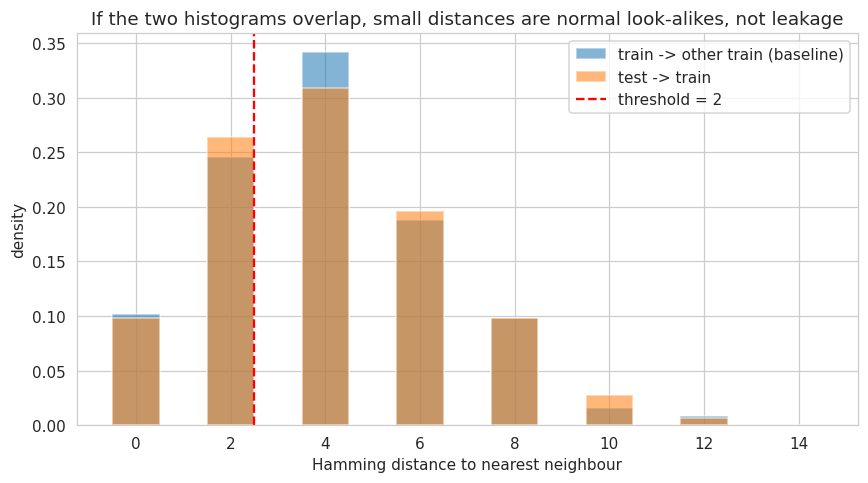

In [10]:
# test -> nearest train image (over all 6 variants), and original-only distance for the calibration plot
n_test = len(test_df)
d_any = np.zeros(n_test, dtype=int); d_orig = np.zeros(n_test, dtype=int)
nn_idx = np.zeros(n_test, dtype=int); nn_var = [""] * n_test
for i in range(n_test):
    best = (99, -1, 0)
    for v in range(test_hv.shape[1]):
        d = hamming_to_all(test_hv[i, v], train_h)
        j = int(d.argmin())
        if v == 0:
            d_orig[i] = int(d[j])
        if int(d[j]) < best[0]:
            best = (int(d[j]), j, v)
    d_any[i], nn_idx[i], nn_var[i] = best[0], best[1], TRANSFORMS[best[2]][0]

# baseline: nearest OTHER train image for 500 random train images
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(train_h), size=min(500, len(train_h)), replace=False)
within = []
for i in sample_idx:
    d = hamming_to_all(train_h[i], train_h); d[i] = 99
    within.append(int(d.min()))
within = np.array(within)

T = NEAR_DUP_THRESHOLD
print(f"Share of images whose nearest neighbour is within Hamming distance {T}:")
print(f"  train -> other train images (BASELINE)      : {np.mean(within <= T):6.1%}")
print(f"  test  -> train images (original only)       : {np.mean(d_orig <= T):6.1%}")
print(f"  test  -> train incl. flips/rotations (FLAG) : {np.mean(d_any <= T):6.1%}")

fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.arange(0, max(within.max(), d_orig.max(), 14) + 2) - 0.5
ax.hist(within, bins=bins, alpha=0.55, density=True, label="train -> other train (baseline)")
ax.hist(d_orig, bins=bins, alpha=0.55, density=True, label="test -> train")
ax.axvline(T + 0.5, color="red", ls="--", label=f"threshold = {T}")
ax.set_xlabel("Hamming distance to nearest neighbour"); ax.set_ylabel("density"); ax.legend()
ax.set_title("If the two histograms overlap, small distances are normal look-alikes, not leakage")
plt.tight_layout(); plt.show()

Test images flagged near-duplicate (distance <= 2): 459 of 651
  ...of which the nearest train image has a DIFFERENT label: 12

Test set composition:


,full,strict (no near-dup)
label_name,,
def_front,453,173
ok_front,198,19



NOTE: the strict subset has fewer than 30 images in one class - treat its metrics as indicative only.


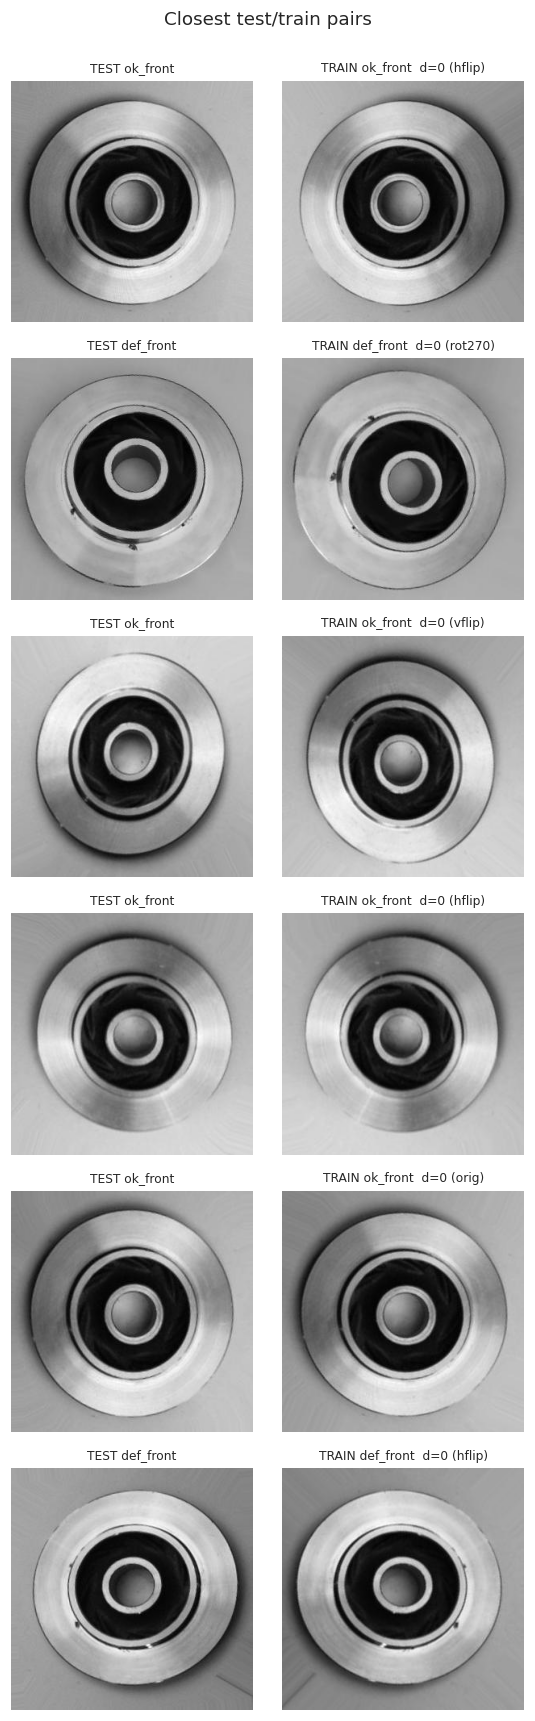

In [11]:
test_df["min_dist"] = d_any
test_df["near_dup"] = d_any <= NEAR_DUP_THRESHOLD
flag = test_df["near_dup"].values

print(f"Test images flagged near-duplicate (distance <= {NEAR_DUP_THRESHOLD}): {int(flag.sum())} of {n_test}")
conflict = int((test_df["label"].values[flag] != train_df["label"].values[nn_idx[flag]]).sum()) if flag.any() else 0
print(f"  ...of which the nearest train image has a DIFFERENT label: {conflict}")
print("\nTest set composition:")
display(pd.DataFrame({"full": test_df["label_name"].value_counts(),
                      "strict (no near-dup)": test_df.loc[~test_df["near_dup"], "label_name"].value_counts()}))
n_strict_min = test_df.loc[~test_df["near_dup"], "label"].value_counts().min() if (~test_df["near_dup"]).any() else 0
if n_strict_min < 30:
    print("\nNOTE: the strict subset has fewer than 30 images in one class - treat its metrics as indicative only.")

# eyeball the closest pairs (is it really the same physical part?)
order = np.argsort(d_any)[:6]
fig, axes = plt.subplots(len(order), 2, figsize=(5.2, 2.6 * len(order)))
for r, i in enumerate(order):
    tr = train_df.iloc[nn_idx[i]]
    axes[r, 0].imshow(Image.open(test_df.filepath[i]).convert("RGB")); axes[r, 0].axis("off")
    axes[r, 0].set_title(f"TEST {test_df.label_name[i]}", fontsize=8)
    axes[r, 1].imshow(Image.open(tr.filepath).convert("RGB")); axes[r, 1].axis("off")
    axes[r, 1].set_title(f"TRAIN {tr.label_name}  d={d_any[i]} ({nn_var[i]})", fontsize=8)
plt.suptitle("Closest test/train pairs", y=1.0); plt.tight_layout(); plt.show()

In [12]:
# Group near-copies inside train (single-linkage on pHash distance) so they cannot straddle train/val
def group_by_hash(arr, thr):
    n = len(arr); parent = np.arange(n)
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x
    for i in tqdm(range(n - 1), desc="grouping train"):
        d = hamming_to_all(arr[i], arr[i + 1:])
        for j in np.nonzero(d <= thr)[0]:
            ri, rj = find(i), find(i + 1 + int(j))
            if ri != rj:
                parent[rj] = ri
    return np.array([find(i) for i in range(n)])

train_df["group"] = group_by_hash(train_h, NEAR_DUP_THRESHOLD)
sizes = train_df["group"].value_counts()
print(f"Train groups: {len(sizes)} for {len(train_df)} images | singletons: {(sizes == 1).sum()} | largest group: {sizes.iloc[0]} images")
if sizes.iloc[0] > 0.03 * len(train_df):
    print("WARNING: one group is very large (chaining). Lower NEAR_DUP_THRESHOLD (e.g. to 1 or 0) and re-run from section 4.")

grouping train:   0%|          | 0/6632 [00:00<?, ?it/s]

Train groups: 4918 for 6633 images | singletons: 4109 | largest group: 41 images


## 5. Train / validation split (stratified **and** grouped)

In [13]:
sgkf = StratifiedGroupKFold(n_splits=VAL_FOLDS, shuffle=True, random_state=SEED)
tr_idx, va_idx = next(sgkf.split(train_df, train_df["label"], groups=train_df["group"]))
train_split_df = train_df.iloc[tr_idx].reset_index(drop=True)
val_split_df = train_df.iloc[va_idx].reset_index(drop=True)
assert set(train_split_df["group"]).isdisjoint(set(val_split_df["group"])), "group leakage between train and val!"

print(f"Train: {len(train_split_df)}   Val: {len(val_split_df)}   Test: {len(test_df)}")
display(pd.DataFrame({"train %": train_split_df["label_name"].value_counts(normalize=True) * 100,
                      "val %": val_split_df["label_name"].value_counts(normalize=True) * 100,
                      "test %": test_df["label_name"].value_counts(normalize=True) * 100}).round(2))
strict_mask = ~test_df["near_dup"].values

Train: 5304   Val: 1329   Test: 651


,train %,val %,test %
label_name,,,
def_front,56.47,57.41,69.59
ok_front,43.53,42.59,30.41


## 6. Brightness-only baseline

Earlier EDA showed good parts are slightly brighter (≈150 vs ≈139). A classifier that sees **only mean and std of brightness**
tells us how much of the task lighting alone can solve. If this baseline is already strong, every CNN result must be
read with that in mind (see sections 10 and 12).

In [14]:
def lum_stats(path):
    a = np.asarray(Image.open(path).convert("L"), dtype=np.float32)
    return [a.mean(), a.std()]

def lum_table(frame):
    return np.array([lum_stats(p) for p in tqdm(frame["filepath"], desc="luminance")])

Xtr, Xva, Xte = lum_table(train_split_df), lum_table(val_split_df), lum_table(test_df)
TRAIN_MEAN_LUM = float(Xtr[:, 0].mean())
print(f"Mean luminance  ok: {Xtr[train_split_df.label.values == 0, 0].mean():.1f}   defect: {Xtr[train_split_df.label.values == 1, 0].mean():.1f}")

lum_clf = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=1000))
lum_clf.fit(Xtr, train_split_df["label"])
rows = []
for name, X, y, m in [("val", Xva, val_split_df["label"].values, slice(None)),
                      ("test", Xte, test_df["label"].values, slice(None)),
                      ("test_strict", Xte[strict_mask], test_df["label"].values[strict_mask], slice(None))]:
    rows.append(dict(split=name, **metrics_at(y, lum_clf.predict_proba(X)[:, 1], 0.5)))
brightness_baseline = pd.DataFrame(rows)
display(brightness_baseline[["split", "n", "acc", "recall", "specificity", "f1", "auc", "FN", "FP"]].round(4))

luminance:   0%|          | 0/5304 [00:00<?, ?it/s]

luminance:   0%|          | 0/1329 [00:00<?, ?it/s]

luminance:   0%|          | 0/651 [00:00<?, ?it/s]

Mean luminance  ok: 150.0   defect: 139.4


,split,n,acc,recall,specificity,f1,auc,FN,FP
0,val,1329,0.8179,0.8467,0.7792,0.8422,0.8929,117,125
1,test,651,0.8310,0.8543,0.7778,0.8756,0.9018,66,44
2,test_strict,192,0.8385,0.8497,0.7368,0.9046,0.8193,26,5


**How to read this:** an AUC around 0.5 means lighting carries no signal; an AUC well above 0.8 means lighting alone separates
a lot of the classes, so a deep model could be (partly) cheating. The robustness tests in section 10 check whether that happens.

## 7. Data loaders, augmentation and loss weights

Augmentation is conservative and **identical for every model**. Brightness jitter (±25%) is deliberately larger than the
class brightness gap (≈8%), so average brightness is a poor shortcut. Vertical flips and ±15° rotations are used because the
part is centred and roughly rotation-symmetric; set `USE_VFLIP = False` if you find that defects are orientation-specific.

In [15]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class EqualizeBrightness:
    # Rescales an image so its mean intensity equals `target` (removes the global-brightness cue).
    def __init__(self, target): self.target = float(target)
    def __call__(self, im):
        a = np.asarray(im, dtype=np.float32)
        scale = self.target / max(float(a.mean()), 1e-6)
        return Image.fromarray(np.clip(a * scale, 0, 255).astype(np.uint8))

class Brightness:
    def __init__(self, factor): self.factor = float(factor)
    def __call__(self, im): return TF.adjust_brightness(im, self.factor)

def build_train_tf():
    steps = [transforms.Resize((IMG_SIZE, IMG_SIZE)),
             transforms.RandomRotation(AUG_ROTATION, fill=(124, 116, 104)),
             transforms.RandomHorizontalFlip(0.5)]
    if USE_VFLIP:
        steps.append(transforms.RandomVerticalFlip(0.5))
    steps.append(transforms.ColorJitter(brightness=AUG_BRIGHTNESS, contrast=AUG_CONTRAST))
    if NORMALIZE_BRIGHTNESS:
        steps.append(EqualizeBrightness(TRAIN_MEAN_LUM))
    steps += [transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
    return transforms.Compose(steps)

def build_eval_tf(extra=None):
    steps = [transforms.Resize((IMG_SIZE, IMG_SIZE))]
    if extra is not None:
        steps.append(extra)                      # used by the robustness tests (section 10)
    if NORMALIZE_BRIGHTNESS:
        steps.append(EqualizeBrightness(TRAIN_MEAN_LUM))
    steps += [transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
    return transforms.Compose(steps)

train_transform = build_train_tf()
eval_transform = build_eval_tf()

class CastingDataset(Dataset):
    def __init__(self, frame, transform):
        self.paths = frame["filepath"].tolist()
        self.labels = frame["label"].astype(int).tolist()
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.transform(img), torch.tensor(self.labels[i], dtype=torch.long)

def make_loader(frame, transform, shuffle=False):
    g = torch.Generator(); g.manual_seed(SEED)
    return DataLoader(CastingDataset(frame, transform), batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=NUM_WORKERS, worker_init_fn=seed_worker, generator=g,
                      pin_memory=(DEVICE.type == "cuda"))

train_loader = make_loader(train_split_df, train_transform, shuffle=True)
train_eval_loader = make_loader(train_split_df, eval_transform)     # train images WITHOUT augmentation (for the true gap)
val_loader = make_loader(val_split_df, eval_transform)
test_loader = make_loader(test_df, eval_transform)
print(f"batches  train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")

batches  train: 166  val: 42  test: 21


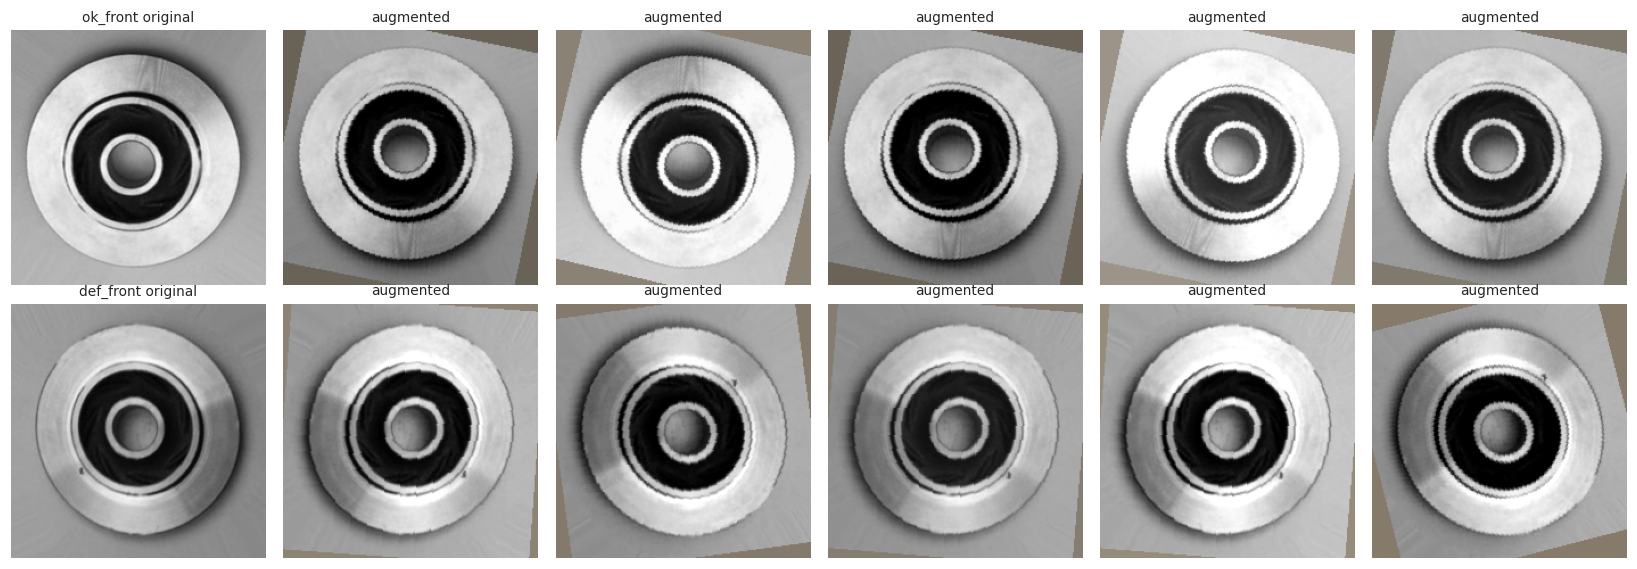

In [16]:
# Augmentation preview (top: ok_front, bottom: def_front)
preview_tf = transforms.Compose(build_train_tf().transforms[:-2])   # everything except ToTensor/Normalize
fig, axes = plt.subplots(2, 6, figsize=(15, 5.2))
for r, cls in enumerate(CLASSES):
    img = Image.open(train_split_df[train_split_df["label_name"] == cls]["filepath"].iloc[0]).convert("RGB")
    axes[r, 0].imshow(img.resize((IMG_SIZE, IMG_SIZE))); axes[r, 0].set_title(f"{cls} original", fontsize=9)
    for c in range(1, 6):
        axes[r, c].imshow(preview_tf(img)); axes[r, c].set_title("augmented", fontsize=9)
for ax in axes.ravel(): ax.axis("off")
plt.tight_layout(); plt.show()

In [17]:
# Loss weights from the TRAIN split only. "balanced" gives each CLASS equal total weight, which makes a single
# defect image count LESS than a good one (defects are the majority). The boost brings per-image weights back
# to roughly equal; the cost-based threshold in section 9 then handles "a missed defect is worse than a false alarm".
counts = train_split_df["label"].value_counts().sort_index().values            # [n_ok, n_def]
balanced = len(train_split_df) / (2 * counts)
class_weights_np = balanced * np.array([1.0, DEFECT_WEIGHT_BOOST])
class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=DEVICE)
print("class counts [ok, defect]:", counts)
print("loss weights [ok, defect]:", class_weights_np.round(3))

class counts [ok, defect]: [2309 2995]
loss weights [ok, defect]: [1.149 1.151]


## 8. Models and training

In [18]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        def block(i, o):
            return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.features = nn.Sequential(block(3, 32), block(32, 64), block(64, 128), block(128, 256))
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(256, 64), nn.ReLU(inplace=True),
                                        nn.Dropout(0.3), nn.Linear(64, num_classes))
    def forward(self, x):
        return self.classifier(self.global_pool(self.features(x)))

def build_effnet(arch, freeze_backbone):
    if arch == "b0":
        m = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1 if PRETRAINED else None)
    elif arch == "b1":
        m = models.efficientnet_b1(weights=EfficientNet_B1_Weights.IMAGENET1K_V1 if PRETRAINED else None)
    else:
        raise ValueError(arch)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, 2)
    if freeze_backbone:
        for n, p in m.named_parameters():
            p.requires_grad = n.startswith("classifier")
    return m

def trainable_params(m): return [p for p in m.parameters() if p.requires_grad]

MODEL_SPECS = {
    "custom_cnn": dict(label="Custom CNN (scratch)", frozen=False,
        build=lambda: CustomCNN(),
        opt=lambda m: optim.AdamW(trainable_params(m), lr=3e-4, weight_decay=1e-4)),
    "effnet_b0_finetune": dict(label="EfficientNet-B0 (full fine-tune)", frozen=False,
        build=lambda: build_effnet("b0", False),
        opt=lambda m: optim.AdamW(trainable_params(m), lr=1e-4, weight_decay=1e-4)),
    "effnet_b1_frozen": dict(label="EfficientNet-B1 (transfer learning, frozen backbone)", frozen=True,
        build=lambda: build_effnet("b1", True),
        opt=lambda m: optim.AdamW(trainable_params(m), lr=1e-3, weight_decay=1e-4)),
}
for k in MODELS_TO_RUN:
    m = MODEL_SPECS[k]["build"]()
    print(f"{k:22s} total params: {sum(p.numel() for p in m.parameters()):>10,}   trainable: {sum(p.numel() for p in trainable_params(m)):>10,}")

custom_cnn             total params:    405,954   trainable:    405,954
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 150MB/s]


effnet_b0_finetune     total params:  4,010,110   trainable:  4,010,110
Downloading: "https://download.pytorch.org/models/efficientnet_b1_rwightman-bac287d4.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1_rwightman-bac287d4.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 174MB/s]


effnet_b1_frozen       total params:  6,515,746   trainable:      2,562


In [19]:
@torch.no_grad()
def predict(model, loader, criterion=None):
    # returns (labels, P(defect), mean loss or None). Always eval mode, no augmentation.
    model.eval()
    ys, ps, loss_sum, n = [], [], 0.0, 0
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        logits = model(x)
        if criterion is not None:
            loss_sum += criterion(logits, y).item() * x.size(0)
        n += x.size(0)
        ps.append(torch.softmax(logits, 1)[:, 1].cpu().numpy())
        ys.append(y.cpu().numpy())
    return np.concatenate(ys), np.concatenate(ps), (loss_sum / n if criterion is not None else None)

def ckpt_payload(name, state):
    return {"state_dict": state, "arch": name, "img_size": IMG_SIZE, "mean": IMAGENET_MEAN, "std": IMAGENET_STD,
            "class_to_idx": LABEL_MAP, "normalize_brightness": NORMALIZE_BRIGHTNESS}

def train_model(model, name, optimizer, criterion, frozen_backbone, ckpt_path):
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=LR_FACTOR, patience=LR_PATIENCE)
    hist = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc", "val_recall", "val_auc", "lr"]}
    best_val, best_state, no_improve = float("inf"), None, 0
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        if frozen_backbone:
            model.features.eval()          # truly frozen: no BatchNorm-stat drift, no stochastic depth
        run_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            run_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
        yv, pv, vloss = predict(model, val_loader, criterion)
        vacc = float(((pv >= 0.5) == yv).mean())
        vrec = float(((pv >= 0.5) & (yv == 1)).sum() / max((yv == 1).sum(), 1))
        vauc = float(roc_auc_score(yv, pv))
        scheduler.step(vloss)
        lr = optimizer.param_groups[0]["lr"]
        for k, v in zip(hist.keys(), [run_loss / total, correct / total, vloss, vacc, vrec, vauc, lr]):
            hist[k].append(float(v))
        print(f"[{name}] ep {epoch:02d}/{MAX_EPOCHS} | train loss {run_loss/total:.4f} acc {correct/total:.4f} | "
              f"val loss {vloss:.4f} acc {vacc:.4f} recall {vrec:.4f} auc {vauc:.4f} | lr {lr:.1e}")
        if vloss < best_val - 1e-4:
            best_val, no_improve = vloss, 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save(ckpt_payload(name, best_state), ckpt_path)      # saved on every improvement (survives disconnects)
        else:
            no_improve += 1
            if no_improve >= EARLY_STOP_PATIENCE:
                print(f"[{name}] early stopping at epoch {epoch}")
                break
    model.load_state_dict(best_state)
    return model, hist

def get_or_train(name):
    spec = MODEL_SPECS[name]
    ckpt = os.path.join(CKPT_DIR, f"{name}.pt")
    hpath = os.path.join(CKPT_DIR, f"{name}_history.json")
    model = spec["build"]().to(DEVICE)
    if os.path.exists(ckpt) and os.path.exists(hpath) and not FORCE_RETRAIN:
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE)["state_dict"])
        with open(hpath) as f:
            hist = json.load(f)
        print(f"[{name}] loaded saved weights from {ckpt}")
        return model, hist
    set_seed(); train_loader.generator.manual_seed(SEED)           # every model starts from the same RNG state
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    model, hist = train_model(model, name, spec["opt"](model), criterion, spec["frozen"], ckpt)
    with open(hpath, "w") as f:
        json.dump(hist, f)
    return model, hist

In [20]:
trained, histories = {}, {}
for name in MODELS_TO_RUN:
    t0 = time.time()
    trained[name], histories[name] = get_or_train(name)
    print(f"--> {name} ready ({(time.time() - t0) / 60:.1f} min)\n")

[custom_cnn] ep 01/20 | train loss 0.6223 acc 0.6533 | val loss 0.6644 acc 0.5794 recall 0.2726 auc 0.9177 | lr 3.0e-04
[custom_cnn] ep 02/20 | train loss 0.4540 acc 0.7986 | val loss 1.7304 acc 0.5741 recall 1.0000 auc 0.8573 | lr 3.0e-04
[custom_cnn] ep 03/20 | train loss 0.3631 acc 0.8465 | val loss 0.3436 acc 0.8450 recall 0.7353 auc 0.9846 | lr 3.0e-04
[custom_cnn] ep 04/20 | train loss 0.3103 acc 0.8731 | val loss 0.6392 acc 0.6817 recall 0.4456 auc 0.9929 | lr 3.0e-04
[custom_cnn] ep 05/20 | train loss 0.2657 acc 0.8939 | val loss 0.7756 acc 0.6637 recall 0.4142 auc 0.9842 | lr 3.0e-04
[custom_cnn] ep 06/20 | train loss 0.2243 acc 0.9108 | val loss 0.6728 acc 0.6674 recall 1.0000 auc 0.9955 | lr 1.5e-04
[custom_cnn] ep 07/20 | train loss 0.1427 acc 0.9491 | val loss 1.0232 acc 0.6245 recall 1.0000 auc 0.9943 | lr 1.5e-04
[custom_cnn] ep 08/20 | train loss 0.1208 acc 0.9623 | val loss 0.0762 acc 0.9842 recall 0.9987 auc 0.9986 | lr 1.5e-04
[custom_cnn] ep 09/20 | train loss 0.112

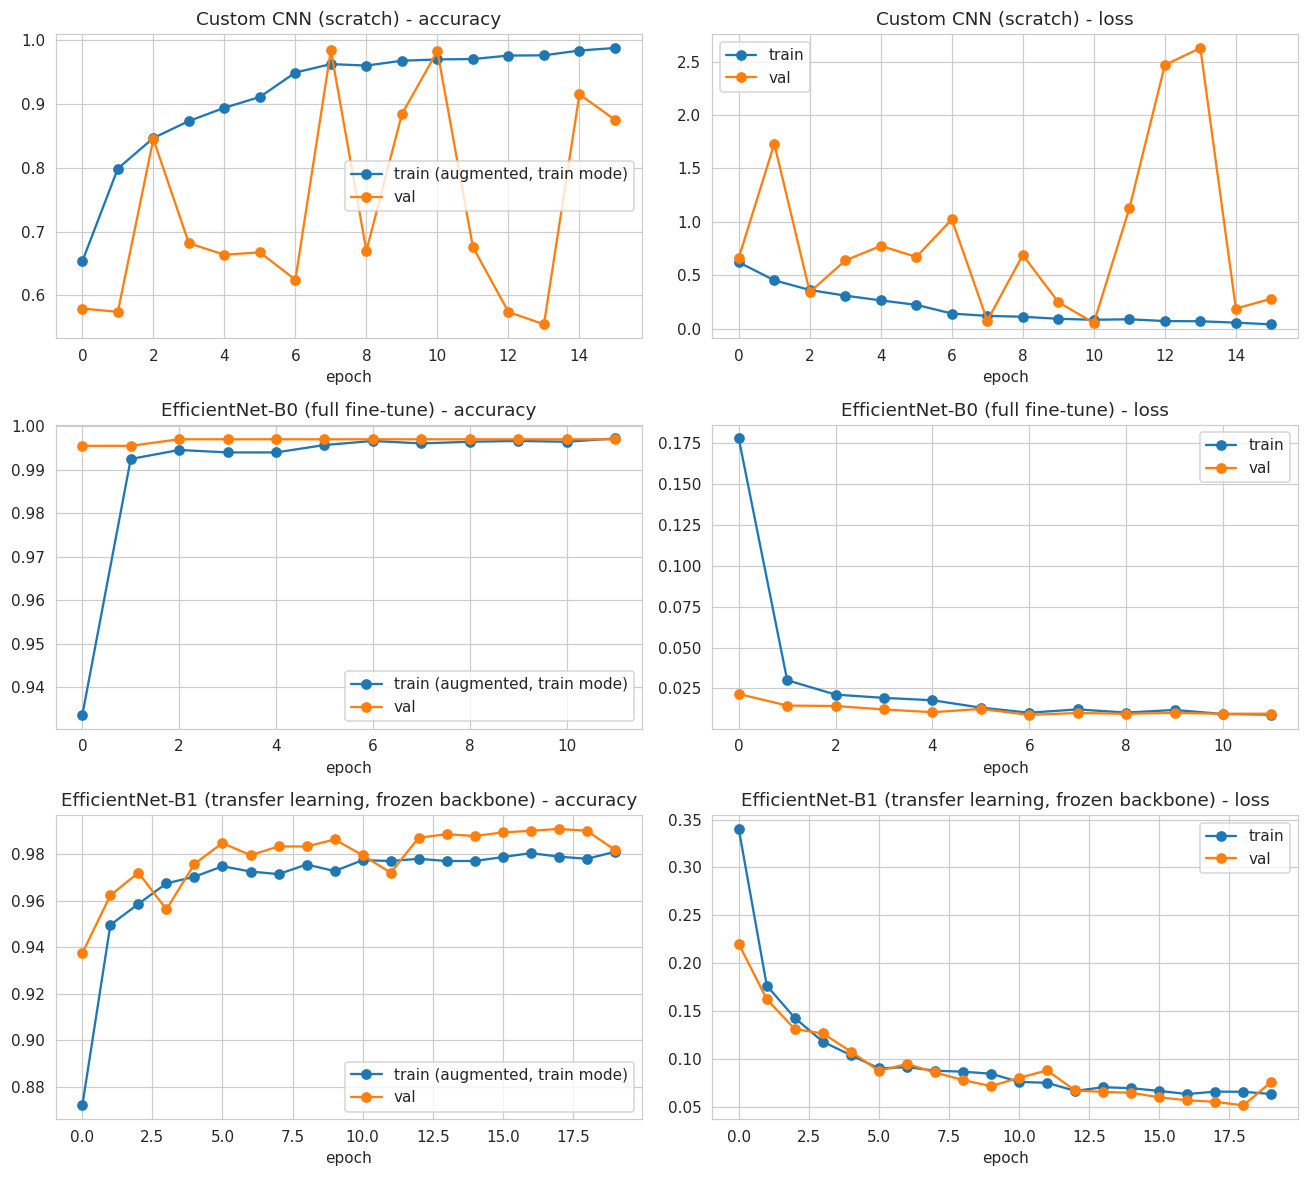

Reminder: the train curves are measured in train mode with augmentation, so they sit BELOW the true train accuracy.
The real train-vs-test gap is computed in section 9 with eval mode and no augmentation.


In [21]:
fig, axes = plt.subplots(len(trained), 2, figsize=(12, 3.6 * len(trained)), squeeze=False)
for r, (name, h) in enumerate(histories.items()):
    axes[r, 0].plot(h["train_acc"], "o-", label="train (augmented, train mode)")
    axes[r, 0].plot(h["val_acc"], "o-", label="val")
    axes[r, 0].set_title(f"{MODEL_SPECS[name]['label']} - accuracy"); axes[r, 0].legend()
    axes[r, 1].plot(h["train_loss"], "o-", label="train"); axes[r, 1].plot(h["val_loss"], "o-", label="val")
    axes[r, 1].set_title(f"{MODEL_SPECS[name]['label']} - loss"); axes[r, 1].legend()
    for c in (0, 1): axes[r, c].set_xlabel("epoch")
plt.tight_layout(); plt.show()
print("Reminder: the train curves are measured in train mode with augmentation, so they sit BELOW the true train accuracy.")
print("The real train-vs-test gap is computed in section 9 with eval mode and no augmentation.")

## 9. Evaluation

* All numbers come from **eval mode, no augmentation**.
* The decision threshold is chosen **on validation only** (minimising `COST_FN·FN + COST_FP·FP`), then applied unchanged to test.
* Two test views: **test** (all images left after exact-duplicate removal) and **test_strict** (also without near-duplicates of train).
* `recall_lo95` is the lower end of the 95% Wilson interval for defect recall — with few images, a perfect score still
  carries real uncertainty.

In [22]:
preds = {k: {"train": predict(m, train_eval_loader)[:2],
             "val": predict(m, val_loader)[:2],
             "test": predict(m, test_loader)[:2]} for k, m in trained.items()}
thresholds = {k: pick_threshold(*preds[k]["val"]) for k in trained}
print("Thresholds tuned on validation:", {k: round(v, 2) for k, v in thresholds.items()})

rows = []
for k in trained:
    for split in ["val", "test", "test_strict"]:
        if split == "test_strict":
            y, p = preds[k]["test"]; y, p = y[strict_mask], p[strict_mask]
        else:
            y, p = preds[k][split]
        for rule, thr in [("0.5", 0.5), ("tuned", thresholds[k])]:
            rows.append(dict(model=k, split=split, rule=rule, **metrics_at(y, p, thr)))
results = pd.DataFrame(rows)

COLS = ["model", "n", "thr", "acc", "recall", "recall_lo95", "specificity", "precision", "f1", "auc", "pr_auc", "FN", "FP"]
def show(split, rule):
    sub = results[(results["split"] == split) & (results["rule"] == rule)]
    print(f"\n=== {split} | threshold rule: {rule} ===")
    display(sub[[c for c in COLS if c in sub.columns]].round(4).reset_index(drop=True))

show("test", "tuned"); show("test_strict", "tuned"); show("test", "0.5"); show("val", "tuned")

Thresholds tuned on validation: {'custom_cnn': 0.1, 'effnet_b0_finetune': 0.21, 'effnet_b1_frozen': 0.41}

=== test | threshold rule: tuned ===


,model,n,thr,acc,recall,recall_lo95,specificity,precision,f1,auc,pr_auc,FN,FP
0,custom_cnn,651,0.10,0.9877,0.9934,0.9807,0.9747,0.989,0.9912,0.9995,0.9998,3,5
1,effnet_b0_finetune,651,0.21,0.9985,0.9978,0.9876,1.0000,1.000,0.9989,1.0000,1.0000,1,0
2,effnet_b1_frozen,651,0.41,0.9892,0.9956,0.9840,0.9747,0.989,0.9923,0.9985,0.9994,2,5



=== test_strict | threshold rule: tuned ===


,model,n,thr,acc,recall,recall_lo95,specificity,precision,f1,auc,pr_auc,FN,FP
0,custom_cnn,192,0.10,0.9896,0.9942,0.968,0.9474,0.9942,0.9942,0.9994,0.9999,1,1
1,effnet_b0_finetune,192,0.21,0.9948,0.9942,0.968,1.0000,1.0000,0.9971,1.0000,1.0000,1,0
2,effnet_b1_frozen,192,0.41,0.9948,0.9942,0.968,1.0000,1.0000,0.9971,0.9991,0.9999,1,0



=== test | threshold rule: 0.5 ===


,model,n,thr,acc,recall,recall_lo95,specificity,precision,f1,auc,pr_auc,FN,FP
0,custom_cnn,651,0.5,0.9539,0.9338,0.9070,1.0000,1.0000,0.9658,0.9995,0.9998,30,0
1,effnet_b0_finetune,651,0.5,0.9969,0.9956,0.9840,1.0000,1.0000,0.9978,1.0000,1.0000,2,0
2,effnet_b1_frozen,651,0.5,0.9923,0.9934,0.9807,0.9899,0.9956,0.9945,0.9985,0.9994,3,2



=== val | threshold rule: tuned ===


,model,n,thr,acc,recall,recall_lo95,specificity,precision,f1,auc,pr_auc,FN,FP
0,custom_cnn,1329,0.10,0.9947,0.9987,0.9926,0.9894,0.9922,0.9954,1.0000,1.0000,1,6
1,effnet_b0_finetune,1329,0.21,0.9977,0.9961,0.9885,1.0000,1.0000,0.9980,0.9999,0.9999,3,0
2,effnet_b1_frozen,1329,0.41,0.9895,0.9882,0.9777,0.9912,0.9934,0.9908,0.9977,0.9986,9,5


In [23]:
# True generalisation gap: every split scored the same way (eval mode, no augmentation, threshold 0.5)
gap = pd.DataFrame({k: {
        "train_acc": float(((preds[k]["train"][1] >= 0.5) == preds[k]["train"][0]).mean()),
        "val_acc":   float(((preds[k]["val"][1] >= 0.5) == preds[k]["val"][0]).mean()),
        "test_acc":  float(((preds[k]["test"][1] >= 0.5) == preds[k]["test"][0]).mean())} for k in trained}).T
gap["train - test"] = gap["train_acc"] - gap["test_acc"]
display(gap.round(4))

,train_acc,val_acc,test_acc,train - test
custom_cnn,0.9840,0.9827,0.9539,0.0301
effnet_b0_finetune,0.9974,0.9970,0.9969,0.0004
effnet_b1_frozen,0.9900,0.9902,0.9923,-0.0023


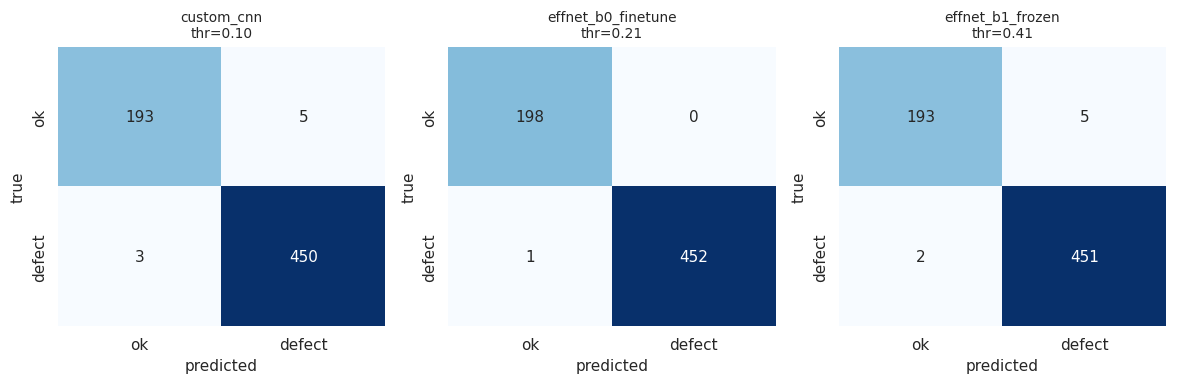

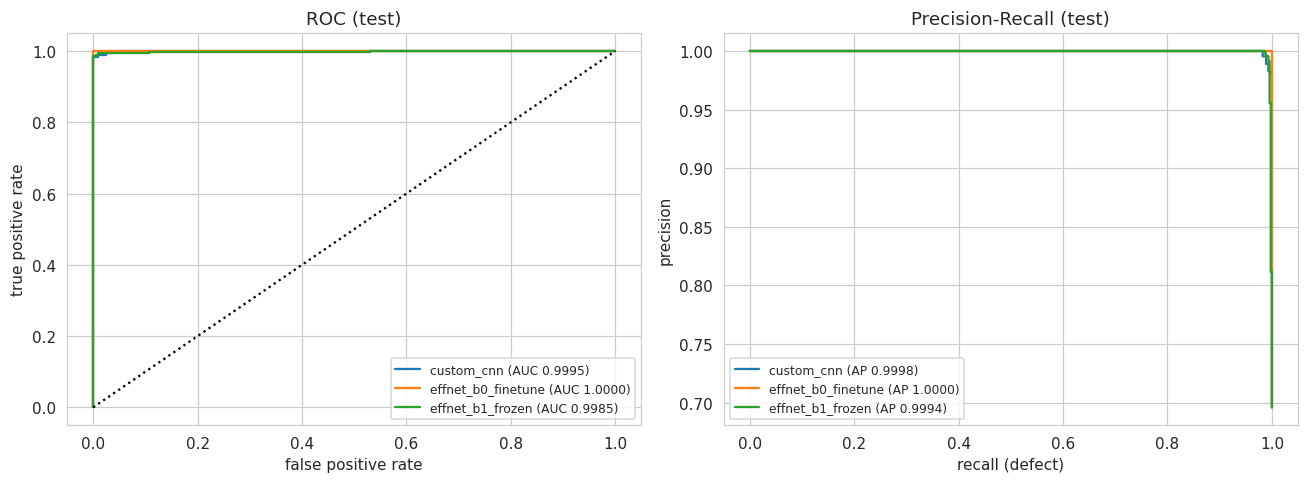

In [24]:
# Confusion matrices on test (tuned threshold) + ROC / PR curves
fig, axes = plt.subplots(1, len(trained), figsize=(3.6 * len(trained), 3.6), squeeze=False)
for ax, k in zip(axes[0], trained):
    y, p = preds[k]["test"]
    cm = confusion_matrix(y, (p >= thresholds[k]).astype(int), labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues", ax=ax,
                xticklabels=["ok", "defect"], yticklabels=["ok", "defect"])
    ax.set_title(f"{k}\nthr={thresholds[k]:.2f}", fontsize=9); ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for k in trained:
    y, p = preds[k]["test"]
    fpr, tpr, _ = roc_curve(y, p); pr, rc, _ = precision_recall_curve(y, p)
    axes[0].plot(fpr, tpr, label=f"{k} (AUC {roc_auc_score(y, p):.4f})")
    axes[1].plot(rc, pr, label=f"{k} (AP {average_precision_score(y, p):.4f})")
axes[0].plot([0, 1], [0, 1], "k:"); axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate"); axes[0].set_title("ROC (test)")
axes[1].set_xlabel("recall (defect)"); axes[1].set_ylabel("precision"); axes[1].set_title("Precision-Recall (test)")
for ax in axes: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [25]:
# Model choice is made on VALIDATION cost (never on test), with a tie-break towards the cheaper model.
val_cost = {}
for k in trained:
    y, p = preds[k]["val"]; pred = p >= thresholds[k]
    val_cost[k] = COST_FN * int(((y == 1) & ~pred).sum()) + COST_FP * int(((y == 0) & pred).sum())
rank = pd.DataFrame({"val_cost": val_cost,
                     "total_params": {k: sum(p.numel() for p in trained[k].parameters()) for k in trained}}).sort_values("val_cost")
display(rank)
# "tied" = within the cost of ONE missed defect of the best model -> prefer the model with fewer total parameters
cand = rank[rank["val_cost"] <= rank["val_cost"].min() + COST_FN]
best_key = cand["total_params"].idxmin()
print(f"Recommended model (lowest validation cost, ties -> smaller model): {best_key}  [{MODEL_SPECS[best_key]['label']}]")
print("Candidates considered tied:", list(cand.index))

,val_cost,total_params
custom_cnn,11.0,405954
effnet_b0_finetune,15.0,4010110
effnet_b1_frozen,50.0,6515746


Recommended model (lowest validation cost, ties -> smaller model): custom_cnn  [Custom CNN (scratch)]
Candidates considered tied: ['custom_cnn', 'effnet_b0_finetune']


## 10. Robustness: does the model rely on brightness?

Two tests on the test set, using each model's tuned threshold:
1. **Brightness sweep** — scale image brightness by 0.7 … 1.3. A model that reads defects from texture/edges should barely move.
2. **Brightness equalisation** — rescale every test image to the same mean brightness (the train average). This removes the global
   brightness cue completely. A large accuracy drop means the model was leaning on it.

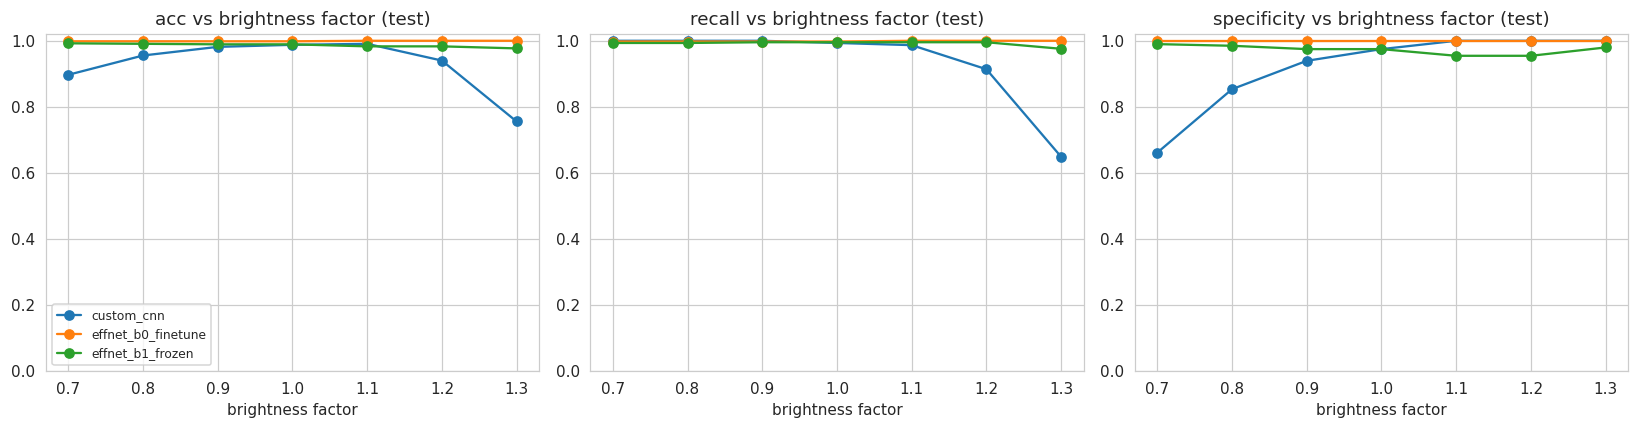

model,custom_cnn,effnet_b0_finetune,effnet_b1_frozen
factor,,,
0.7,0.8971,0.9985,0.9923
0.8,0.9555,0.9985,0.9908
0.9,0.9816,0.9985,0.9892
1.0,0.9877,0.9985,0.9892
1.1,0.9908,1.0000,0.9831
1.2,0.9401,1.0000,0.9831
1.3,0.7558,1.0000,0.9770


In [26]:
FACTORS = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]
rob_rows = []
for k, m in trained.items():
    for f in FACTORS:
        y, p, _ = predict(m, make_loader(test_df, build_eval_tf(Brightness(f))))
        r = metrics_at(y, p, thresholds[k])
        rob_rows.append(dict(model=k, factor=f, acc=r["acc"], recall=r["recall"], specificity=r["specificity"]))
rob = pd.DataFrame(rob_rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["acc", "recall", "specificity"]):
    for k in trained:
        s = rob[rob["model"] == k]; ax.plot(s["factor"], s[metric], "o-", label=k)
    ax.set_title(f"{metric} vs brightness factor (test)"); ax.set_xlabel("brightness factor"); ax.set_ylim(0, 1.02)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()
display(rob.pivot(index="factor", columns="model", values="acc").round(4))

In [27]:
eq_rows = []
for k, m in trained.items():
    y, p, _ = predict(m, make_loader(test_df, build_eval_tf(EqualizeBrightness(TRAIN_MEAN_LUM))))
    r_eq = metrics_at(y, p, thresholds[k])
    r_no = metrics_at(*preds[k]["test"], thresholds[k])
    eq_rows.append(dict(model=k, acc=r_no["acc"], acc_equalised=r_eq["acc"], acc_drop=r_no["acc"] - r_eq["acc"],
                        recall=r_no["recall"], recall_equalised=r_eq["recall"],
                        specificity=r_no["specificity"], specificity_equalised=r_eq["specificity"]))
equalised = pd.DataFrame(eq_rows).set_index("model")
display(equalised.round(4))
for k, row in equalised.iterrows():
    if row["acc_drop"] >= 0.05:
        print(f"!! {k}: accuracy falls {row['acc_drop']:.1%} when brightness is equalised -> it likely relies on global brightness.")
if (equalised["acc_drop"] < 0.05).all():
    print("No model loses 5+ accuracy points when brightness is equalised: no evidence of a brightness shortcut.")
else:
    print("\nSuggested fix: set NORMALIZE_BRIGHTNESS = True and RUN_TAG = 'brightness_norm' in CONFIG and run again.")

,acc,acc_equalised,acc_drop,recall,recall_equalised,specificity,specificity_equalised
model,,,,,,,
custom_cnn,0.9877,0.9770,0.0108,0.9934,0.9890,0.9747,0.9495
effnet_b0_finetune,0.9985,0.9985,0.0000,0.9978,0.9978,1.0000,1.0000
effnet_b1_frozen,0.9892,0.9892,0.0000,0.9956,0.9956,0.9747,0.9747


No model loses 5+ accuracy points when brightness is equalised: no evidence of a brightness shortcut.


## 11. Error analysis

Images that several models get wrong are the ones to look at: they are either genuinely hard, or **mislabelled**.

Test images misclassified by at least one model: 14 (of 651)


,filename,true,near_dup,n_models_wrong,p_def[custom_cnn],p_def[effnet_b0_finetune],p_def[effnet_b1_frozen]
0,cast_ok_0_16.jpeg,ok_front,True,2,0.112,0.140,0.595
1,cast_def_0_1591.jpeg,def_front,False,2,0.716,0.152,0.128
2,new__0_6223.jpeg,def_front,True,1,0.077,1.000,0.996
3,cast_ok_0_2911.jpeg,ok_front,True,1,0.160,0.100,0.064
4,cast_ok_0_1316.jpeg,ok_front,True,1,0.187,0.114,0.088
5,new__0_3973.jpeg,def_front,True,1,0.080,1.000,0.996
6,cast_ok_0_7560.jpeg,ok_front,False,1,0.116,0.094,0.373
7,cast_def_0_646.jpeg,def_front,False,1,0.054,1.000,1.000
8,cast_ok_0_7839.jpeg,ok_front,True,1,0.123,0.131,0.199
9,cast_ok_0_1925.jpeg,ok_front,True,1,0.001,0.000,0.654


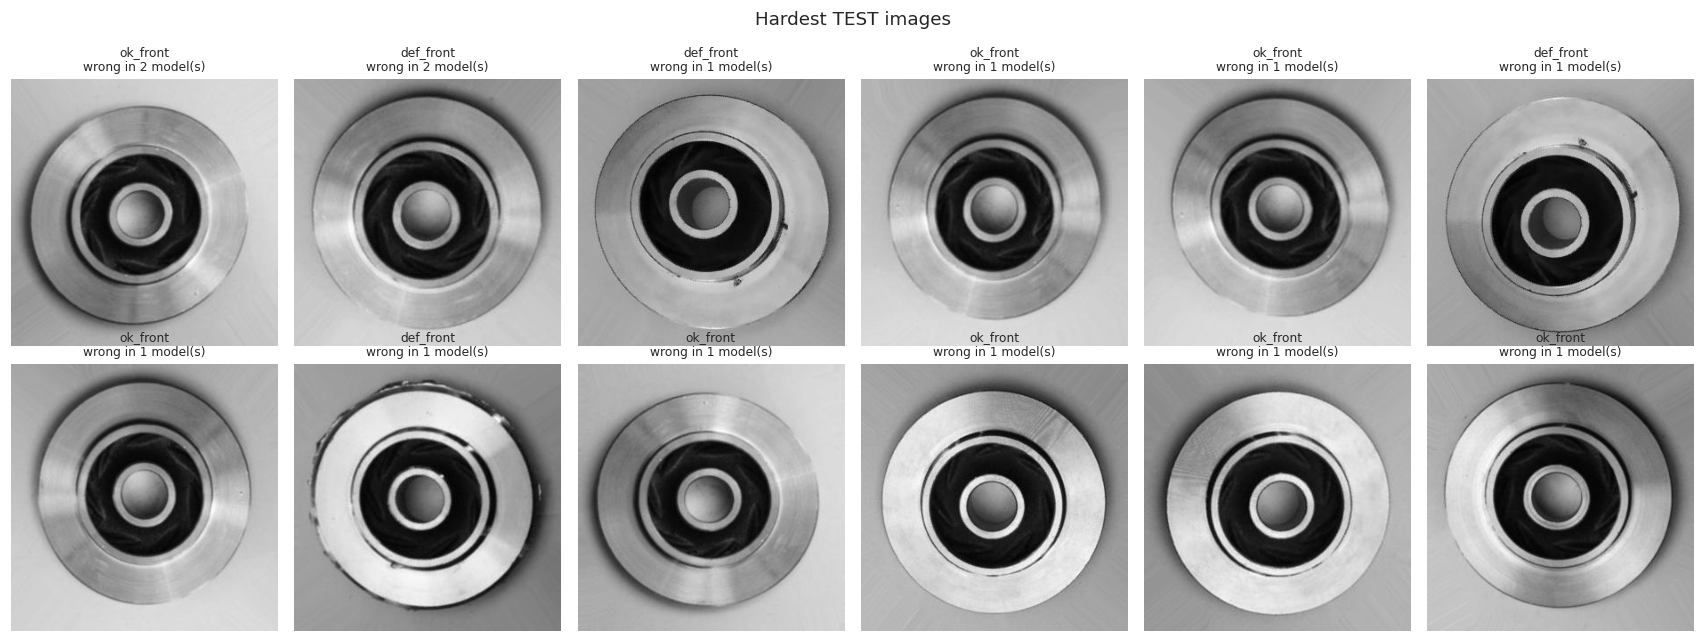


Validation images misclassified by at least one model: 20 (of 1329)


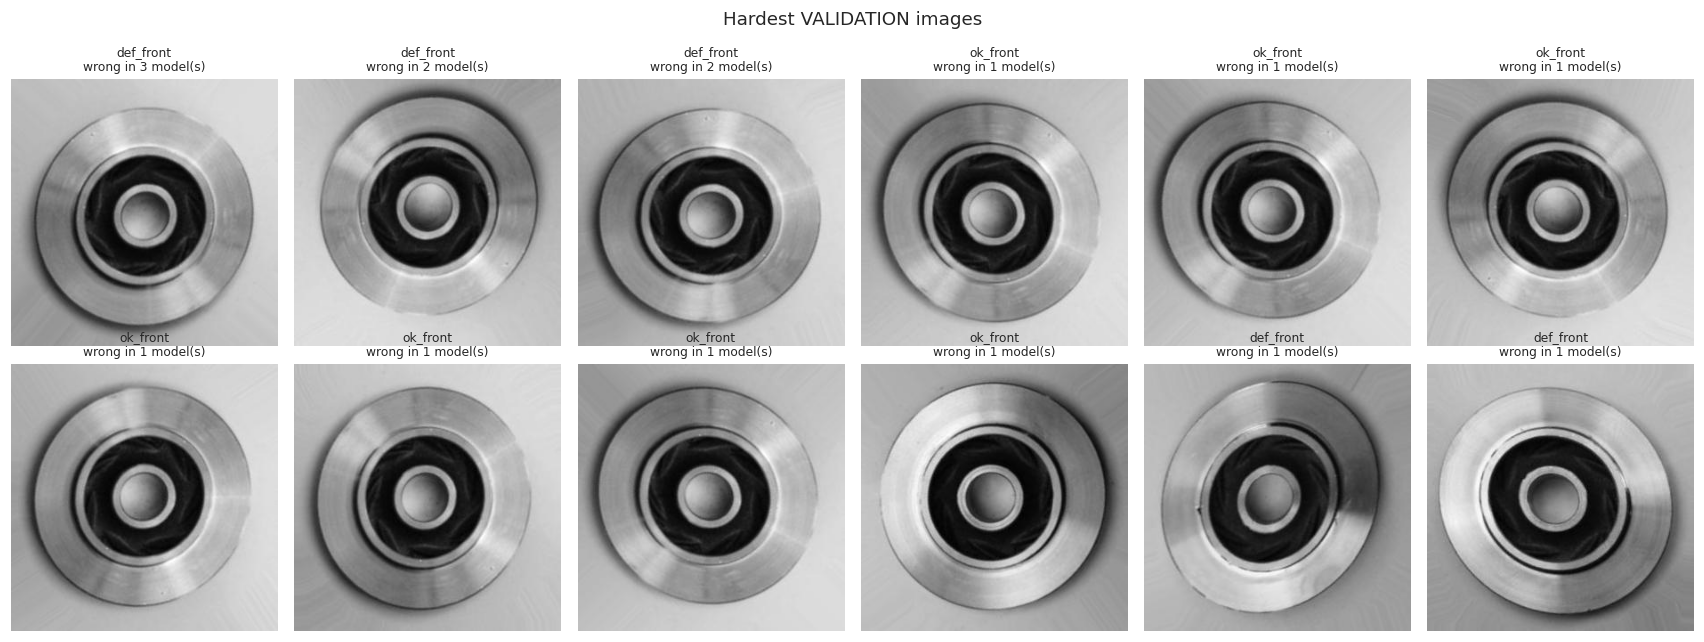

In [28]:
def wrong_set(k, split):
    y, p = preds[k][split]
    return set(int(i) for i in np.flatnonzero((p >= thresholds[k]).astype(int) != y))

def show_grid(frame, idxs, titles, ncols=6, suptitle=None):
    if len(idxs) == 0:
        print("(none)"); return
    nrows = int(np.ceil(len(idxs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.6 * ncols, 2.9 * nrows)); axes = np.atleast_1d(axes).ravel()
    for ax in axes: ax.axis("off")
    for ax, i, t in zip(axes, idxs, titles):
        ax.imshow(Image.open(frame["filepath"].iloc[i]).convert("RGB")); ax.set_title(t, fontsize=8)
    if suptitle: plt.suptitle(suptitle, y=1.0)
    plt.tight_layout(); plt.show()

# ---- test errors ----
cnt = Counter(i for k in trained for i in wrong_set(k, "test"))
hard_idx = [i for i, _ in cnt.most_common()]
print(f"Test images misclassified by at least one model: {len(hard_idx)} (of {len(test_df)})")
if hard_idx:
    err_table = pd.DataFrame({"filename": [test_df["filename"][i] for i in hard_idx],
                              "true": [test_df["label_name"][i] for i in hard_idx],
                              "near_dup": [bool(test_df["near_dup"][i]) for i in hard_idx],
                              "n_models_wrong": [cnt[i] for i in hard_idx],
                              **{f"p_def[{k}]": [round(float(preds[k]["test"][1][i]), 3) for i in hard_idx] for k in trained}})
    display(err_table.head(20))
    show_grid(test_df, hard_idx[:12],
              [f"{test_df['label_name'][i]}\nwrong in {cnt[i]} model(s)" for i in hard_idx[:12]], suptitle="Hardest TEST images")

# ---- validation errors ----
vcnt = Counter(i for k in trained for i in wrong_set(k, "val"))
v_hard = [i for i, _ in vcnt.most_common()]
print(f"\nValidation images misclassified by at least one model: {len(v_hard)} (of {len(val_split_df)})")
show_grid(val_split_df, v_hard[:12],
          [f"{val_split_df['label_name'][i]}\nwrong in {vcnt[i]} model(s)" for i in v_hard[:12]], suptitle="Hardest VALIDATION images")

**How to read this:** for each image shown, ask whether the *label* looks right. If several strong models agree with each other
and disagree with the label, treat it as probable label noise rather than a model failure.

## 12. Grad-CAM — where does each model look?

Rows = models, columns = test images (3 defective, 3 good, plus up to 2 hard cases). Warm colours mark the image regions that
pushed the model towards **"defect"**. For defective parts the heat should sit on the defect or its surroundings. If it
covers the whole part uniformly or sits on the background, the model is probably using something other than the defect.

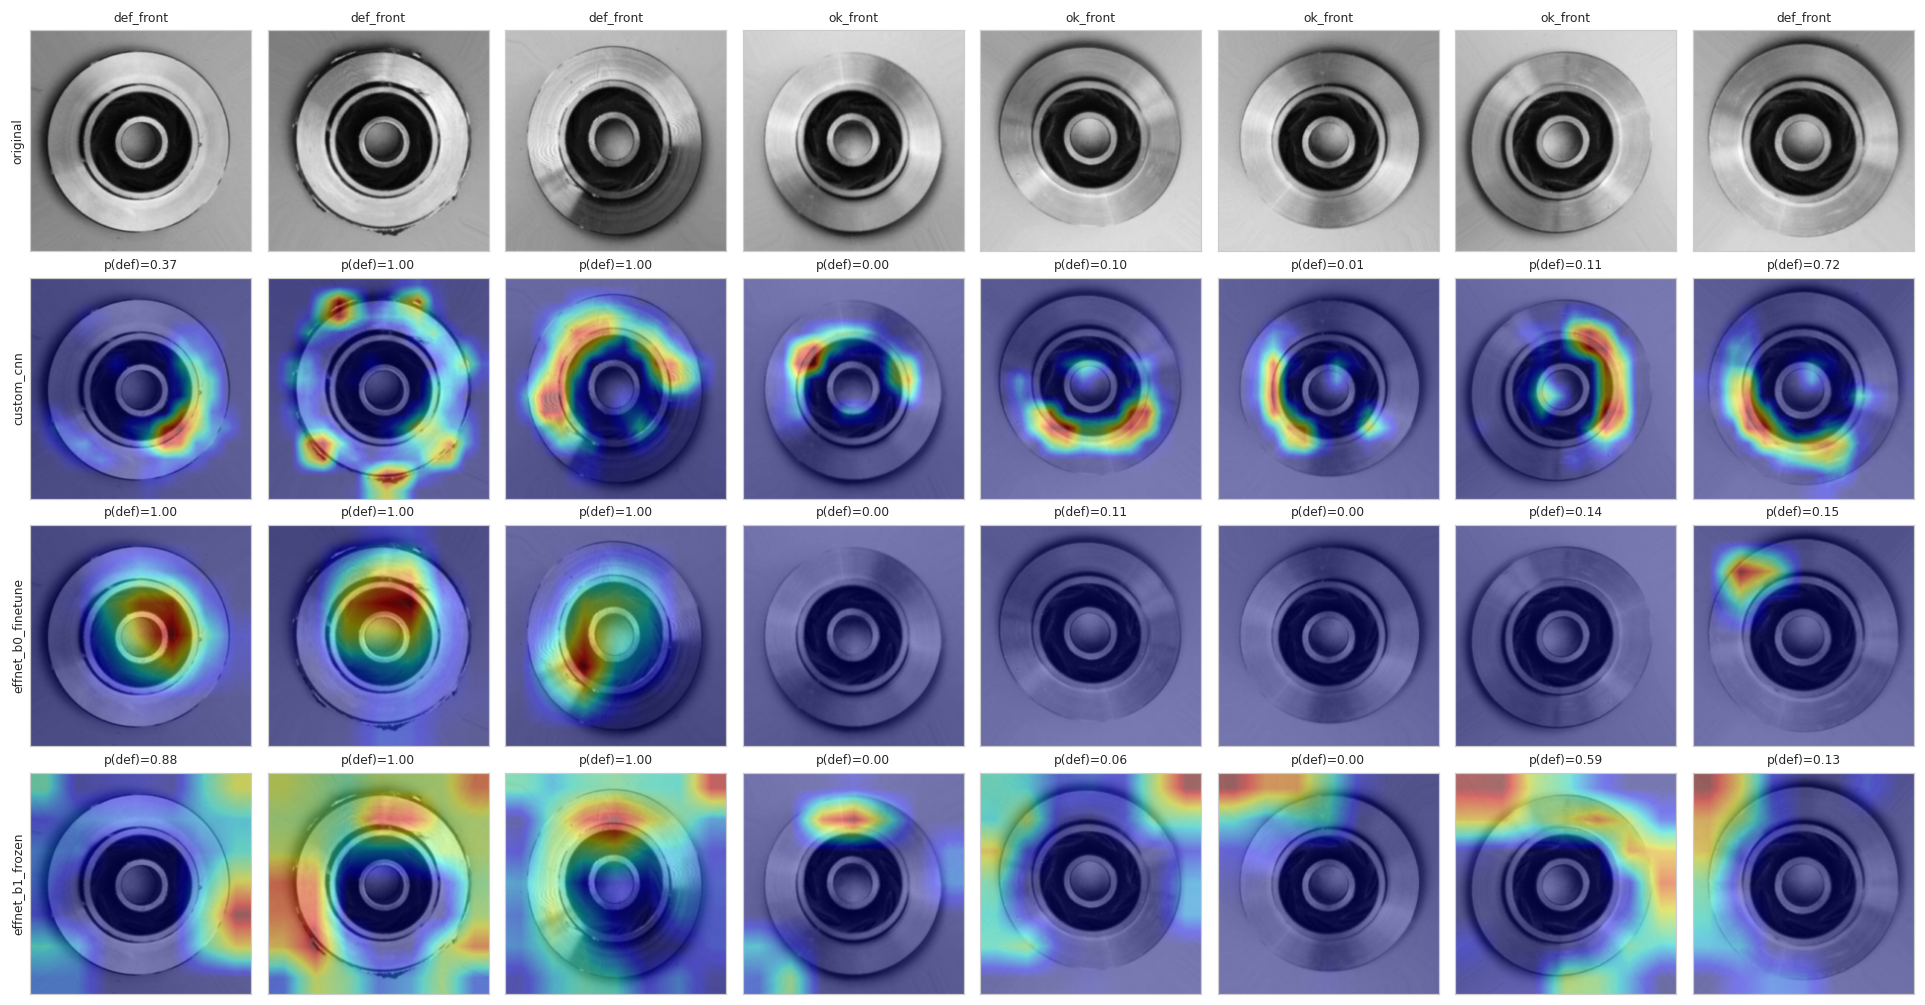

In [29]:
def grad_cam(model, x, class_idx=1):
    model.eval()
    store = {}
    layer = model.features[-1]
    def fwd_hook(module, inp, out):
        store["act"] = out
        out.register_hook(lambda g: store.__setitem__("grad", g))
    handle = layer.register_forward_hook(fwd_hook)
    x = x.clone().to(DEVICE).requires_grad_(True)
    try:
        logits = model(x)
        model.zero_grad(set_to_none=True)
        logits[:, class_idx].sum().backward()
    finally:
        handle.remove()
    act, grad = store["act"].detach(), store["grad"].detach()
    w = grad.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((w * act).sum(dim=1, keepdim=True))
    cam = cam / (cam.amax(dim=(2, 3), keepdim=True) + 1e-8)
    cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
    return cam[:, 0].cpu().numpy(), torch.softmax(logits.detach(), 1)[:, 1].cpu().numpy()

rng = np.random.default_rng(SEED)
y_all = test_df["label"].values
idxs = (list(rng.choice(np.flatnonzero(y_all == 1), 3, replace=False))
        + list(rng.choice(np.flatnonzero(y_all == 0), 3, replace=False))
        + [int(i) for i in hard_idx[:2]])
X = torch.stack([eval_transform(Image.open(test_df["filepath"][i]).convert("RGB")) for i in idxs])
mean_t = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1); std_t = torch.tensor(IMAGENET_STD).view(1, 3, 1, 1)
disp = (X * std_t + mean_t).clamp(0, 1).permute(0, 2, 3, 1).numpy()

nrows, ncols = len(trained) + 1, len(idxs)
fig, axes = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 2.3 * nrows), squeeze=False)
for c, i in enumerate(idxs):
    axes[0, c].imshow(disp[c]); axes[0, c].set_title(f"{test_df['label_name'][i]}", fontsize=8)
for r, (k, m) in enumerate(trained.items(), start=1):
    cams, probs = grad_cam(m, X)
    for c in range(ncols):
        axes[r, c].imshow(disp[c]); axes[r, c].imshow(cams[c], cmap="jet", alpha=0.45)
        axes[r, c].set_title(f"p(def)={probs[c]:.2f}", fontsize=8)
    axes[r, 0].set_ylabel(k, fontsize=8)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
for r, k in enumerate(["original"] + list(trained), start=0):
    axes[r, 0].set_ylabel(k, fontsize=8)
plt.tight_layout(); plt.show()

## 13. Save results and the inference config

Everything needed to **deploy** goes into `CKPT_DIR`: weights (`<model>.pt`), training histories, the result tables, the exact
split manifest, and `inference_config.json` (class mapping, image size, normalisation, per-model decision threshold).
The inference code must apply the same `eval_transform` and the model's tuned threshold.

In [30]:
results.to_csv(os.path.join(CKPT_DIR, "results_all.csv"), index=False)
rob.to_csv(os.path.join(CKPT_DIR, "robustness_brightness.csv"), index=False)
equalised.to_csv(os.path.join(CKPT_DIR, "robustness_equalised.csv"))
brightness_baseline.to_csv(os.path.join(CKPT_DIR, "brightness_baseline.csv"), index=False)

manifest = pd.concat([train_split_df.assign(role="train"), val_split_df.assign(role="val"),
                      test_df.assign(role="test")], ignore_index=True)
manifest[["filepath", "filename", "label_name", "label", "role", "md5", "group", "near_dup", "min_dist"]].to_csv(os.path.join(CKPT_DIR, "split_manifest.csv"), index=False)

inference_config = {
    "class_to_idx": LABEL_MAP, "positive_class": "def_front", "img_size": IMG_SIZE,
    "mean": IMAGENET_MEAN, "std": IMAGENET_STD,
    "normalize_brightness": NORMALIZE_BRIGHTNESS, "train_mean_luminance": TRAIN_MEAN_LUM,
    "cost_fn": COST_FN, "cost_fp": COST_FP,
    "models": {k: {"checkpoint": f"{k}.pt", "threshold": thresholds[k]} for k in trained},
    "recommended": best_key,
}
with open(os.path.join(CKPT_DIR, "inference_config.json"), "w") as f:
    json.dump(inference_config, f, indent=2)
print("Saved to", CKPT_DIR)
print(sorted(os.listdir(CKPT_DIR)))

Saved to /content/drive/MyDrive/casting_v2/baseline
['brightness_baseline.csv', 'custom_cnn.pt', 'custom_cnn_history.json', 'effnet_b0_finetune.pt', 'effnet_b0_finetune_history.json', 'effnet_b1_frozen.pt', 'effnet_b1_frozen_history.json', 'inference_config.json', 'results_all.csv', 'robustness_brightness.csv', 'robustness_equalised.csv', 'split_manifest.csv']


## 14. Final comparison and how to write the summary

In [31]:
final = results[(results["rule"] == "tuned") & (results["split"].isin(["test", "test_strict"]))]
final = final.pivot(index="model", columns="split", values=["recall", "specificity", "FN", "FP", "auc"])
final["val_cost"] = rank["val_cost"]; final["total_params"] = rank["total_params"]
display(final.round(4))
print("Brightness-only baseline (test): AUC =", round(float(brightness_baseline.loc[brightness_baseline.split == "test", "auc"].iloc[0]), 4))

recall             specificity               FN  \
split                 test test_strict        test test_strict test   
model                                                                 
custom_cnn          0.9934      0.9942      0.9747      0.9474  3.0   
effnet_b0_finetune  0.9978      0.9942      1.0000      1.0000  1.0   
effnet_b1_frozen    0.9956      0.9942      0.9747      1.0000  2.0   

                                 FP                 auc             val_cost  \
split              test_strict test test_strict    test test_strict            
model                                                                          
custom_cnn                 1.0  5.0         1.0  0.9995      0.9994     11.0   
effnet_b0_finetune         1.0  0.0         0.0  1.0000      1.0000     15.0   
effnet_b1_frozen           1.0  5.0         0.0  0.9985      0.9991     50.0   

                   total_params  
split                            
model                            
custom_cnn               405954  
effnet_b0_finetune      4010110  
effnet_b1_frozen        6515746

Brightness-only baseline (test): AUC = 0.9018


### Rules for the written summary (so the conclusions match the numbers)

* **Rank by defect recall and the FN/FP counts at the tuned threshold**, not by the train-test gap. A small gap with low accuracy means
  *under*-fitting, not good generalisation.
* **Always report both test views** and the Wilson lower bound on recall. If test results are perfect, say the benchmark is
  **saturated** and cannot separate the models, and rely on validation cost, robustness and cost-to-run for the choice.
* **Never claim inference cost from trainable-parameter counts.** Freezing a backbone only reduces *training* cost; inference cost depends on
  the whole network (see `total_params` above).
* **State the brightness baseline and the robustness result** (section 10). If a model collapses under equalised brightness,
  say it relies on lighting and retrain with `NORMALIZE_BRIGHTNESS = True`.
* **State the data caveats**: near-duplicate counts, the strict-subset size, and how many error cases looked like label noise.
* **Fine-tune vs transfer learning:** `effnet_b0_finetune` vs `effnet_b1_frozen` changes architecture *and* strategy together, so
  describe it as "a fully fine-tuned B0 vs a frozen-backbone B1", not as a pure test of fine-tuning vs transfer learning.
* **Frozen B1 is the cheapest to *train* but not to *run*:** it has the most total parameters of the three (see `total_params`).
* **Deployment**: ship the recommended model with its tuned threshold from `inference_config.json`; keep training and inference code separate.